Lendo e ajustando dataframe

In [104]:
import pandas as pd

df = pd.read_parquet('../data.parquet')

In [105]:
# filtrando indicadores para serem utilizados

indicadores = ['rais_10_1', 'rais_10_3', 'rais_5_1', 'rais_8_6', 'rais_8_2']

df = df.query('id_indicator in @indicadores').reset_index(drop=True)

In [106]:
df

,value,id_indicator,id_local
0,0.2353,rais_5_1,2500106
1,0.0789,rais_5_1,2500205
2,0.3547,rais_5_1,2500304
3,0.2945,rais_5_1,2500403
4,0.3248,rais_5_1,2500502
...,...,...,...
1110,0.0000,rais_10_3,2517100
1111,1974.5578,rais_10_1,2517209
1112,0.0370,rais_10_3,2517209
1113,2919.4725,rais_10_1,2517407


a) Construa o dendrograma da clusterização hierárquica aglomerativa. Compare pelo menos três métodos de
ligação (por exemplo, ward, complete e average). Calcule o coeficiente de correlação cofenética de cada método
e indique qual preserva melhor as distâncias originais.

In [107]:
# pivotando a base para trabalhar com algoritmos

df_wide = (
    df
    .pivot(index="id_local",
           columns="id_indicator",
           values="value")
)
df_wide

id_indicator,rais_10_1,rais_10_3,rais_5_1,rais_8_2,rais_8_6
id_local,,,,,
2500106,1862.6632,0.0294,0.2353,0.0000,0.0294
2500205,1815.3953,0.0526,0.0789,0.0000,0.0526
2500304,1870.3547,0.0533,0.3547,0.0000,0.1200
2500403,1707.4569,0.0030,0.2945,0.0015,0.0254
2500502,1626.6457,0.0342,0.3248,0.0000,0.0427
...,...,...,...,...,...
2516904,2355.6326,0.0161,0.3855,0.0000,0.1486
2517001,1312.5083,0.1389,0.5000,0.0000,0.1111
2517100,1589.4194,0.0000,0.4062,0.0000,0.0938


In [108]:
df_wide.isna().sum()

id_indicator
rais_10_1    0
rais_10_3    0
rais_5_1     0
rais_8_2     0
rais_8_6     0
dtype: int64

In [109]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

modelo = AgglomerativeClustering(
    n_clusters=2,
    linkage="average"
)

labels = modelo.fit_predict(X)

pd.Series(labels).value_counts()
print(silhouette_score(X, labels))

0.8153499644461111


In [110]:
# como não temos valores ausentes não precisamos inputar, agora vamos seguir para a padronização por conta da remuneração (rais_10_1) estar na casa dos milhares

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(df_wide)
X

array([[-0.22941043, -0.11050809, -0.35032008, -0.27456295, -0.55087778],
       [-0.28548182,  0.33396415, -1.2400865 , -0.27456295, -0.37539574],
       [-0.22028642,  0.34737495,  0.32895173, -0.27456295,  0.13440982],
       ...,
       [-0.55354495, -0.6737617 ,  0.62193747, -0.27456295, -0.06376385],
       [-0.09667585,  0.03509489, -1.37264122, -0.27456295, -0.77325587],
       [ 1.02422594, -0.6737617 , -0.26669114, -0.27456295,  1.11771433]],
      shape=(223, 5))

In [111]:
# agora vamos comparar os métodos de ligação

from scipy.cluster.hierarchy import linkage

Z_ward = linkage(X, method="ward")
Z_complete = linkage(X, method="complete")
Z_average = linkage(X, method="average")

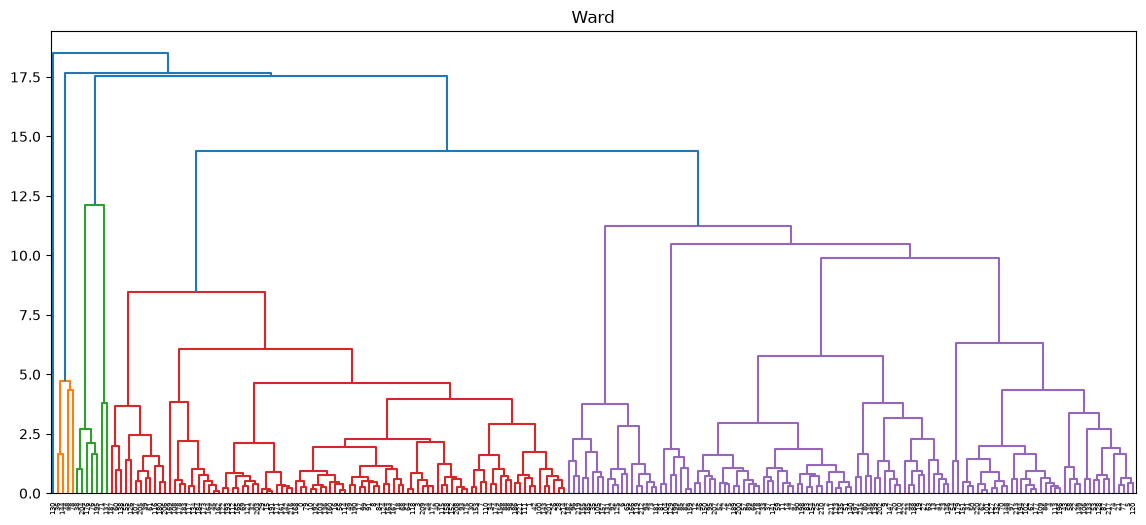

In [112]:
# construindo o dendrograma

import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(14,6))
dendrogram(Z_ward)
plt.title("Ward")
plt.show()

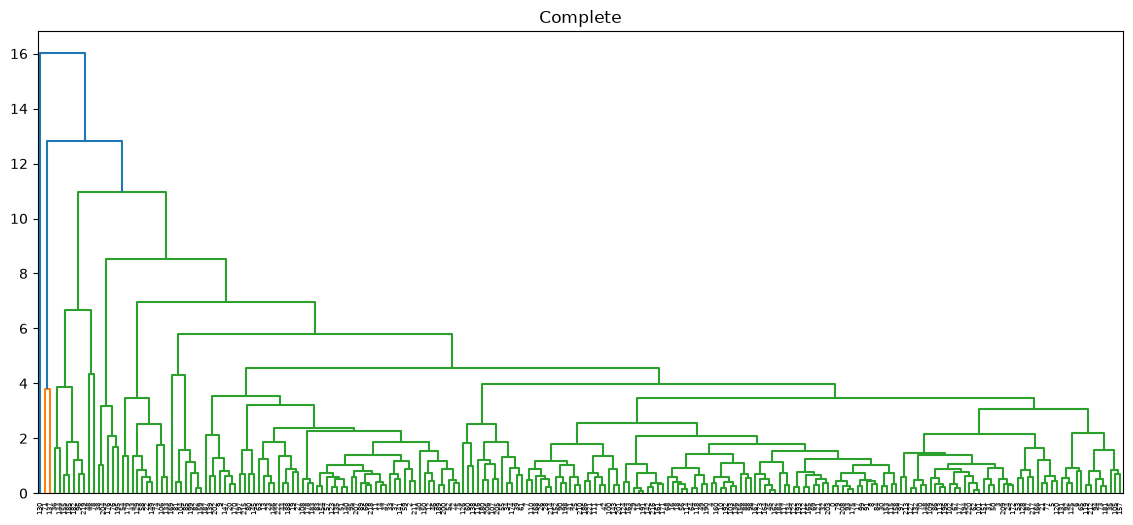

In [113]:
# construindo o dendrograma

import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(14,6))
dendrogram(Z_complete)
plt.title("Complete")
plt.show()

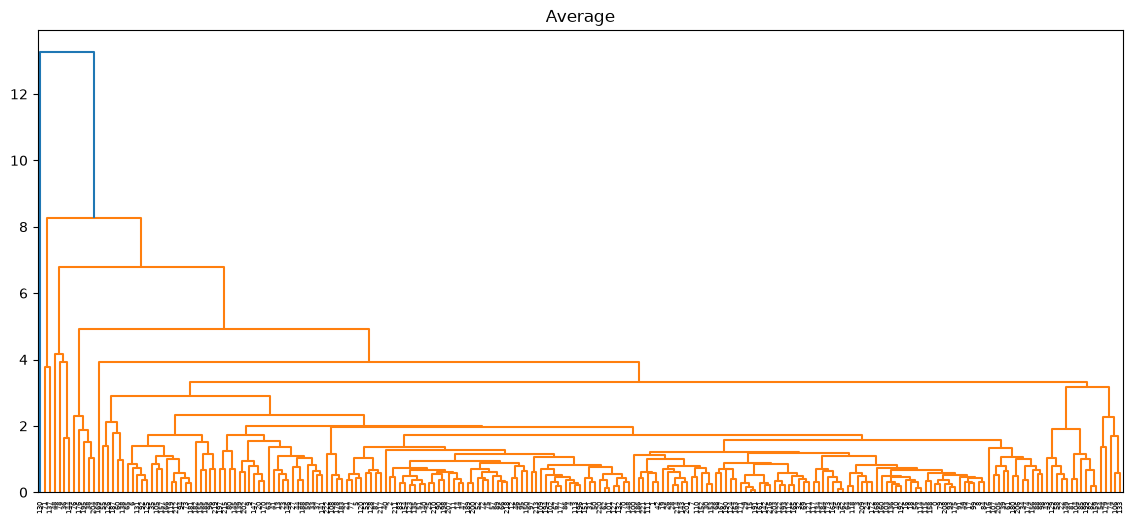

In [114]:
# construindo o dendrograma

import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(14,6))
dendrogram(Z_average)
plt.title("Average")
plt.show()

In [115]:
# agora vamos checar e comparar com as distancias originais usando os coeficientes de correlação cofenética

from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import pdist

dist = pdist(X)

coph_ward, _ = cophenet(Z_ward, dist)
coph_complete, _ = cophenet(Z_complete, dist)
coph_average, _ = cophenet(Z_average, dist)

print(coph_ward)
print(coph_complete)
print(coph_average)

0.5317387055136865
0.8143988576942189
0.9294966220685378


Aqui vimos que o coph_average deu o maior coeficiente de correlação cofenética, ou seja, teve a melhor representação no dendrograma diante as distâncias originais, com isso escolhemos o método "average"

b) A partir do dendrograma do método escolhido, defina um ponto de corte e obtenha um número k de grupos. Justifique o corte (use também a silhueta como apoio) e adicione ao DataFrame uma coluna com o grupo de cada município.

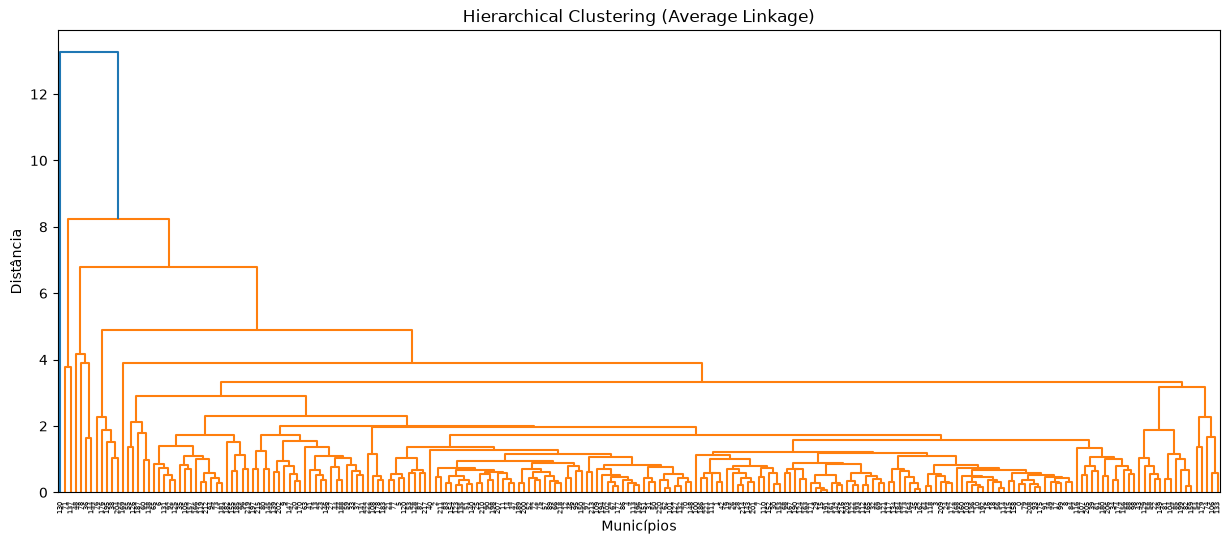

In [116]:
# vamos analisar o dendrograma mais uma vez do metodo average

import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(15, 6))
dendrogram(Z_average)
plt.title("Hierarchical Clustering (Average Linkage)")
plt.xlabel("Municípios")
plt.ylabel("Distância")
plt.show()

In [117]:
# aqui vemos que a distancia = 7.5 é um bom corte por conta do grande salto vertical em d = 8, logo vamos testar com 7.5

from scipy.cluster.hierarchy import fcluster
import numpy as np

grupos = fcluster(Z_average, t=6, criterion="distance")

In [118]:
print("Número de grupos:", len(np.unique(grupos)))

Número de grupos: 4


In [119]:
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster

silhuetas = {}

for k in range(2, 11):
    grupos = fcluster(Z_average, t=k, criterion="maxclust")
    score = silhouette_score(X, grupos)
    silhuetas[k] = score

silhuetas

{2: 0.8153499644461111,
 3: 0.7129555345083964,
 4: 0.6690971411306452,
 5: 0.5741485894449887,
 6: 0.5660692689360632,
 7: 0.4662474125897695,
 8: 0.460686921032575,
 9: 0.4587901104300656,
 10: 0.41181638649236274}

In [120]:
for d in np.arange(8, 10, 0.1):
    grupos = fcluster(Z_average, t=d, criterion="distance")
    print(f"{d:.1f} -> {len(np.unique(grupos))}")

8.0 -> 3
8.1 -> 3
8.2 -> 3
8.3 -> 2
8.4 -> 2
8.5 -> 2
8.6 -> 2
8.7 -> 2
8.8 -> 2
8.9 -> 2
9.0 -> 2
9.1 -> 2
9.2 -> 2
9.3 -> 2
9.4 -> 2
9.5 -> 2
9.6 -> 2
9.7 -> 2
9.8 -> 2
9.9 -> 2


In [121]:
# como ficamos com k=2, vamos seguir a adicionando a coluna

from scipy.cluster.hierarchy import fcluster

grupos = fcluster(Z_average, t=4, criterion="maxclust")

pd.Series(grupos).value_counts()

3    216
2      4
1      2
4      1
Name: count, dtype: int64

Temos um problema aqui de outlier, vamos tentar ajeitar

In [122]:
df_wide["grupo"] = grupos

df_wide[df_wide["grupo"] == 2]

id_indicator,rais_10_1,rais_10_3,rais_5_1,rais_8_2,rais_8_6,grupo
id_local,,,,,,
2502706,1595.97,0.3077,0.5385,0.0,0.2308,2
2503753,2298.00,0.3333,0.6667,0.0,0.6667,2
2505907,1411.23,0.4000,1.0000,0.0,0.2000,2
2511707,1607.99,0.2857,0.2857,0.0,0.1429,2


In [123]:
df_wide.describe()

id_indicator,rais_10_1,rais_10_3,rais_5_1,rais_8_2,rais_8_6,grupo
count,223.000000,223.000000,223.000000,223.000000,223.000000,223.000000
mean,2056.055069,0.035168,0.296878,0.002955,0.102230,2.968610
std,844.891590,0.052314,0.176172,0.010787,0.132505,0.239935
min,1209.716700,0.000000,0.000000,0.000000,0.000000,1.000000
25%,1543.440900,0.000000,0.179000,0.000000,0.031100,3.000000
50%,1852.899200,0.024400,0.283200,0.000000,0.070000,3.000000
75%,2252.576750,0.042250,0.389000,0.001950,0.128000,3.000000
max,7033.370700,0.400000,1.000000,0.142900,1.000000,4.000000


O método de ligação **average** apresentou o maior coeficiente de correlação cofenética (0,929), indicando a melhor preservação das distâncias originais. Entretanto, ao definir o número de grupos, observou-se que a solução com dois grupos isolou um único município dos demais. A inspeção dos dados revelou que esse município possui a maior taxa de lesões ocupacionais (`rais_8_2`) da base, com valor muito superior ao segundo maior observado, além de apresentar elevados percentuais de participação feminina e trabalhadores com ensino superior. Esse comportamento faz com que o método **average** trate o município como um outlier, produzindo uma partição pouco informativa para fins de caracterização dos perfis municipais.

Embora a análise da silhueta tenha indicado **k = 2** como a melhor solução em termos de separação entre os grupos, essa configuração não atende adequadamente ao objetivo da atividade, uma vez que resulta em um grupo composto por apenas um município. Além de dificultar a interpretação dos perfis encontrados, essa solução inviabiliza o atendimento ao item (c) da atividade, que solicita a caracterização de cada grupo e a identificação de três municípios representativos por grupo.

Dessa forma, optou-se por adotar uma solução com **k = 4** grupos. Embora essa escolha apresente um coeficiente de silhueta inferior ao obtido para **k = 2**, ela permite uma segmentação mais informativa dos municípios e torna possível a comparação entre diferentes perfis socioeconômicos. Assim, a escolha de **k = 4** privilegia a interpretabilidade dos resultados e está mais alinhada com o objetivo da análise, que consiste em identificar perfis municipais capazes de subsidiar discussões sobre políticas de emprego e renda, sem desconsiderar a existência do município atípico identificado na etapa anterior.


c) Caracterize cada grupo pela média dos indicadores e proponha um rótulo interpretativo (por exemplo,
“mercados de alta remuneração e alta escolaridade”). Preencha a tabela abaixo e liste três municípios
representativos por grupo.

In [124]:
from scipy.cluster.hierarchy import fcluster

grupos = fcluster(Z_average, t=4, criterion="maxclust")

df_wide["grupo"] = grupos

In [125]:
perfil = (
    df_wide
    .groupby("grupo")
    .agg(
        n_municipios=("grupo", "size"),
        rais_10_1=("rais_10_1", "mean"),
        rais_10_3=("rais_10_3", "mean"),
        rais_5_1=("rais_5_1", "mean"),
        rais_8_6=("rais_8_6", "mean"),
        rais_8_2=("rais_8_2", "mean"),
    )
)

perfil

,n_municipios,rais_10_1,rais_10_3,rais_5_1,rais_8_6,rais_8_2
grupo,,,,,,
1,2,4899.075050,0.000000,0.000000,1.00000,0.000000
2,4,1728.297500,0.331675,0.622725,0.31010,0.000000
3,216,2037.383824,0.030166,0.292983,0.08988,0.002389
4,1,1714.034300,0.000000,0.428600,0.14290,0.142900


In [126]:
import numpy as np
from scipy.spatial.distance import cdist

representativos = {}

for grupo in sorted(df_wide["grupo"].unique()):

    dados_grupo = df_wide[df_wide["grupo"] == grupo]

    # remove a coluna grupo
    Xg = dados_grupo.drop(columns="grupo")

    # padroniza usando o mesmo scaler da análise
    Xg_scaled = scaler.transform(Xg)

    # centro do grupo
    centroide = Xg_scaled.mean(axis=0)

    # distância ao centro
    distancias = cdist(Xg_scaled, [centroide])

    # três menores distâncias
    idx = np.argsort(distancias[:,0])[:3]

    representativos[grupo] = dados_grupo.iloc[idx].index.tolist()

representativos

{np.int32(1): ['2505303', '2511004'],
 np.int32(2): ['2502706', '2511707', '2505907'],
 np.int32(3): ['2507002', '2515302', '2516201'],
 np.int32(4): ['2510402']}

In [127]:
for grupo, municipios in representativos.items():
    print(f"Grupo {grupo}: {municipios}")

Grupo 1: ['2505303', '2511004']
Grupo 2: ['2502706', '2511707', '2505907']
Grupo 3: ['2507002', '2515302', '2516201']
Grupo 4: ['2510402']


In [128]:
tabela_2_1 = (
    df_wide
    .groupby("grupo")
    .agg(
        **{
            "Nº mun.": ("grupo", "size"),
            "rais_10_1": ("rais_10_1", "mean"),
            "rais_10_3": ("rais_10_3", "mean"),
            "rais_5_1": ("rais_5_1", "mean"),
            "rais_8_6": ("rais_8_6", "mean"),
            "rais_8_2": ("rais_8_2", "mean"),
        }
    )
    .round(4)
)

tabela_2_1.index.name = "Grupo"

tabela_2_1

,Nº mun.,rais_10_1,rais_10_3,rais_5_1,rais_8_6,rais_8_2
Grupo,,,,,,
1,2,4899.0750,0.0000,0.0000,1.0000,0.0000
2,4,1728.2975,0.3317,0.6227,0.3101,0.0000
3,216,2037.3838,0.0302,0.2930,0.0899,0.0024
4,1,1714.0343,0.0000,0.4286,0.1429,0.1429


d) Discussão: compare o resultado hierárquico com um K-Means usando o mesmo k (por exemplo, por meio de
uma tabela de contingência entre os dois rótulos, verificando o quanto os agrupamentos coincidem) e comente
se os métodos concordam. Aponte também vantagens e desvantagens da clusterização hierárquica frente ao K-
Means neste problema e discuta como os grupos encontrados poderiam informar políticas de emprego e renda.

In [129]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df_wide["grupo_kmeans"] = kmeans.fit_predict(X)

In [130]:
df_wide["grupo_hierarquico"] = grupos

In [131]:
import pandas as pd

contingencia = pd.crosstab(
    df_wide["grupo_hierarquico"],
    df_wide["grupo_kmeans"],
    margins=True
)

contingencia

grupo_kmeans,0,1,2,3,All
grupo_hierarquico,,,,,
1,0,0,2,0,2
2,0,4,0,0,4
3,211,0,5,0,216
4,0,0,0,1,1
All,211,4,7,1,223


A comparação entre a clusterização hierárquica e o K-Means foi realizada por meio de uma tabela de contingência entre os rótulos produzidos pelos dois métodos. Observa-se elevada concordância entre as soluções obtidas. Os grupos menores identificados pela clusterização hierárquica foram integralmente preservados pelo K-Means, enquanto o maior grupo apresentou apenas uma pequena divergência, com cinco municípios sendo realocados para outro cluster. Dessa forma, conclui-se que ambos os métodos identificaram uma estrutura semelhante para os dados, diferindo apenas na classificação de um número reduzido de municípios.

Os agrupamentos identificados permitem segmentar os municípios segundo características do mercado de trabalho formal. Municípios pertencentes a grupos com maior remuneração média e maior participação de trabalhadores com ensino superior podem receber políticas voltadas ao fortalecimento da inovação e da qualificação profissional. Já grupos caracterizados por menor remuneração e maior proporção de vínculos de baixa renda podem ser priorizados por programas de capacitação, incentivo à formalização e atração de investimentos. Além disso, o município identificado como atípico deve ser analisado individualmente, pois seu comportamento pode indicar características específicas do mercado de trabalho local ou a necessidade de investigação mais detalhada.

Apesar da elevada concordância entre os métodos, a clusterização hierárquica evidenciou maior sensibilidade à presença de municípios atípicos, produzindo grupos de pequena dimensão. O K-Means, por sua vez, gerou uma partição ligeiramente mais homogênea, embora ambos tenham identificado praticamente a mesma estrutura geral dos dados.